# Crédit Scoring Bancaire — Modèle à Haut Risque (AI Act)

⚠️ **Risque élevé** — Annexe III §5b | Voir [README.md](README.md) et [GOVERNANCE_REFERENCE.md](GOVERNANCE_REFERENCE.md)

## 0. Dépendances optionnelles

In [1]:
# Author: Octo Technology MLOps Tribe
# SHAP : explicabilité locale du modèle
# Pandera : validation formelle du schéma de données
%pip install shap pandera --quiet

/Users/louis.delmas/Documents/Stage/model_platform/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## 1. Imports

In [2]:
# Author: Octo Technology MLOps Tribe
import json
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import pandera as pa
from mlflow.models.signature import infer_signature
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
ARTIFACTS_DIR = Path(tempfile.mkdtemp())
print(f"Répertoire artefacts temporaires : {ARTIFACTS_DIR}")

/Users/louis.delmas/Documents/Stage/model_platform/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Répertoire artefacts temporaires : /var/folders/7v/nkhkrj4n2cv816zr_kcbm36h0000gn/T/tmpfguln18n


## 2. Configuration MLflow

In [3]:
# Author: Octo Technology MLOps Tribe
# ⚙️ Adapter l'URI à votre projet Model Platform
PROJECT_NAME = "Credit-Risk-Assessment"
MLFLOW_TRACKING_URI = f"http://model-platform.com/registry/{PROJECT_NAME}/"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("credit_default_prediction")
print(f"MLflow tracking URI : {MLFLOW_TRACKING_URI}")

2026/06/02 09:55:41 INFO mlflow.tracking.fluent: Experiment with name 'credit_default_prediction' does not exist. Creating a new experiment.


MLflow tracking URI : http://model-platform.com/registry/Credit-Risk-Assessment/


## 3. Génération des données synthétiques

In [4]:
# Author: Octo Technology MLOps Tribe
np.random.seed(42)
N = 8000

age                  = np.random.randint(22, 70, N)
income               = np.random.randint(15_000, 150_000, N)
loan_amount          = np.random.randint(1_000, 80_000, N)
loan_duration_months = np.random.choice([12, 24, 36, 48, 60, 84], N)
credit_score         = np.random.randint(300, 850, N)
num_existing_loans   = np.random.randint(0, 6, N)
employment_years     = np.random.randint(0, 35, N)
missed_payments_12m  = np.random.randint(0, 5, N)
debt_to_income_ratio = np.clip(loan_amount / income, 0, 5).round(4)
loan_to_income_ratio = np.clip(loan_amount / income, 0, 5).round(4)

# Probabilité de défaut (modèle logistique)
log_odds = (
    -3.5
    + 0.008 * np.maximum(0, 35 - age)
    - 0.000012 * income
    + 0.000025 * loan_amount
    - 0.004 * credit_score
    + 0.25 * num_existing_loans
    - 0.04 * employment_years
    + 1.8 * debt_to_income_ratio
    + 0.4 * missed_payments_12m
)
prob_default = 1 / (1 + np.exp(-log_odds))
default = (np.random.rand(N) < prob_default).astype(int)

FEATURES = [
    "age", "income", "loan_amount", "loan_duration_months",
    "credit_score", "num_existing_loans", "employment_years",
    "missed_payments_12m", "debt_to_income_ratio", "loan_to_income_ratio",
]
TARGET = "default"
PROTECTED_ATTRIBUTES = ["age", "income"]

df = pd.DataFrame({
    "age":                  age,
    "income":               income,
    "loan_amount":          loan_amount,
    "loan_duration_months": loan_duration_months,
    "credit_score":         credit_score,
    "num_existing_loans":   num_existing_loans,
    "employment_years":     employment_years,
    "missed_payments_12m":  missed_payments_12m,
    "debt_to_income_ratio": debt_to_income_ratio,
    "loan_to_income_ratio": loan_to_income_ratio,
    "default":              default,
})

print(f"Dataset : {len(df):,} lignes | Taux de défaut : {df['default'].mean():.1%}")

Dataset : 8,000 lignes | Taux de défaut : 9.1%


## 4. Validation Pandera & statistiques descriptives

In [5]:
# Author: Octo Technology MLOps Tribe
# ── Définition du schéma Pandera ──────────────────────────────────────────────
CREDIT_SCHEMA = pa.DataFrameSchema(
    name="credit_scoring_input_schema",
    description="Contrat de données du modèle de scoring crédit — AI Act Annexe IV §2d",
    columns={
        "age": pa.Column(
            int,
            checks=pa.Check.in_range(18, 100),
            nullable=False,
            description="Âge de l'emprunteur (années) — ⚠️ attribut protégé RGPD / AI Act",
        ),
        "income": pa.Column(
            int,
            checks=pa.Check.in_range(0, 2_000_000),
            nullable=False,
            description="Revenu annuel brut (€) — ⚠️ attribut protégé RGPD / AI Act",
        ),
        "loan_amount": pa.Column(
            int,
            checks=pa.Check.in_range(1, 1_000_000),
            nullable=False,
            description="Montant du prêt demandé (€)",
        ),
        "loan_duration_months": pa.Column(
            int,
            checks=pa.Check.isin([12, 24, 36, 48, 60, 84]),
            nullable=False,
            description="Durée du prêt — valeurs autorisées : 12, 24, 36, 48, 60, 84 mois",
        ),
        "credit_score": pa.Column(
            int,
            checks=pa.Check.in_range(300, 850),
            nullable=False,
            description="Score de crédit interne (300 = très mauvais, 850 = excellent)",
        ),
        "num_existing_loans": pa.Column(
            int,
            checks=pa.Check.in_range(0, 50),
            nullable=False,
            description="Nombre de crédits en cours",
        ),
        "employment_years": pa.Column(
            int,
            checks=pa.Check.in_range(0, 60),
            nullable=False,
            description="Ancienneté dans l'emploi actuel (années)",
        ),
        "missed_payments_12m": pa.Column(
            int,
            checks=pa.Check.in_range(0, 12),
            nullable=False,
            description="Paiements manqués sur les 12 derniers mois",
        ),
        "debt_to_income_ratio": pa.Column(
            float,
            checks=pa.Check.in_range(0.0, 100.0),
            nullable=False,
            description="Ratio dette totale / revenu annuel (variable dérivée)",
        ),
        "loan_to_income_ratio": pa.Column(
            float,
            checks=pa.Check.in_range(0.0, 100.0),
            nullable=False,
            description="Ratio montant du prêt / revenu annuel (variable dérivée)",
        ),
        "default": pa.Column(
            int,
            checks=pa.Check.isin([0, 1]),
            nullable=False,
            description="Variable cible : 1 = défaut de paiement, 0 = remboursement normal",
        ),
    },
    coerce=False,
    strict=True,
)

# ── Validation ────────────────────────────────────────────────────────────────
try:
    CREDIT_SCHEMA.validate(df, lazy=True)
    PANDERA_STATUS = "PASS"
    PANDERA_ERRORS = 0
    print("✅ Validation Pandera : SUCCÈS — le dataset est conforme au schéma")
except pa.errors.SchemaErrors as exc:
    PANDERA_STATUS = "FAIL"
    PANDERA_ERRORS = len(exc.failure_cases)
    print(f"❌ Validation Pandera : ÉCHEC ({PANDERA_ERRORS} erreurs)")
    print(exc.failure_cases.to_string())

✅ Validation Pandera : SUCCÈS — le dataset est conforme au schéma


In [6]:
# Author: Octo Technology MLOps Tribe
# ── Statistiques descriptives ─────────────────────────────────────────────────
print("=== Statistiques descriptives (features + target) ===")
display(df[FEATURES + [TARGET]].describe().round(3))

print("\n=== Valeurs manquantes ===")
missing = df.isnull().sum()
print(missing[missing > 0].to_string() if missing.any() else "Aucune valeur manquante.")

print(f"\n=== Distribution de la variable cible ===")
print(f"Non défaut (0) : {(df[TARGET] == 0).sum():,}  ({(df[TARGET] == 0).mean():.1%})")
print(f"Défaut     (1) : {(df[TARGET] == 1).sum():,}  ({(df[TARGET] == 1).mean():.1%})")
print(f"Ratio de déséquilibre : {(df[TARGET] == 0).sum() / (df[TARGET] == 1).sum():.1f}:1")

# Distribution des attributs protégés
AGE_BINS    = [18, 30, 45, 60, 100]
AGE_LABELS  = ["18-30", "31-45", "46-60", "60+"]
INC_BINS    = [0, 30_000, 60_000, 100_000, 200_000]
INC_LABELS  = ["<30k", "30k-60k", "60k-100k", ">100k"]

age_groups    = pd.cut(df["age"],    bins=AGE_BINS, labels=AGE_LABELS)
income_groups = pd.cut(df["income"], bins=INC_BINS, labels=INC_LABELS)

print("\n=== Distribution par tranche d'âge (attribut protégé) ===")
age_dist = age_groups.value_counts().sort_index()
for label, count in age_dist.items():
    dr = df.loc[age_groups == label, TARGET].mean()
    print(f"  {label:<8} : {count:>5} obs  | taux de défaut : {dr:.1%}")

print("\n=== Distribution par tranche de revenu (attribut protégé) ===")
income_dist = income_groups.value_counts().sort_index()
for label, count in income_dist.items():
    dr = df.loc[income_groups == label, TARGET].mean()
    print(f"  {label:<10} : {count:>5} obs  | taux de défaut : {dr:.1%}")

=== Statistiques descriptives (features + target) ===


,age,income,loan_amount,loan_duration_months,credit_score,num_existing_loans,employment_years,missed_payments_12m,debt_to_income_ratio,loan_to_income_ratio,default
count,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000,8000.000
mean,45.590,82083.052,40149.765,44.223,574.610,2.502,16.854,1.999,0.691,0.691,0.091
std,13.745,39258.025,22921.028,23.477,158.933,1.696,10.092,1.415,0.698,0.698,0.288
min,22.000,15005.000,1014.000,12.000,300.000,0.000,0.000,0.000,0.007,0.007,0.000
25%,34.000,47699.500,19650.250,24.000,439.000,1.000,8.000,1.000,0.244,0.244,0.000
50%,45.000,82163.000,40272.000,48.000,573.000,3.000,17.000,2.000,0.486,0.486,0.000
75%,57.000,116171.250,60028.250,60.000,711.000,4.000,26.000,3.000,0.860,0.860,0.000
max,69.000,149997.000,79996.000,84.000,849.000,5.000,34.000,4.000,5.000,5.000,1.000



=== Valeurs manquantes ===
Aucune valeur manquante.

=== Distribution de la variable cible ===
Non défaut (0) : 7,272  (90.9%)
Défaut     (1) : 728  (9.1%)
Ratio de déséquilibre : 10.0:1

=== Distribution par tranche d'âge (attribut protégé) ===
  18-30    :  1445 obs  | taux de défaut : 9.0%
  31-45    :  2560 obs  | taux de défaut : 9.5%
  46-60    :  2501 obs  | taux de défaut : 9.4%
  60+      :  1494 obs  | taux de défaut : 8.0%

=== Distribution par tranche de revenu (attribut protégé) ===
  <30k       :   897 obs  | taux de défaut : 39.2%
  30k-60k    :  1812 obs  | taux de défaut : 12.6%
  60k-100k   :  2317 obs  | taux de défaut : 4.0%
  >100k      :  2974 obs  | taux de défaut : 1.8%


In [7]:
# Author: Octo Technology MLOps Tribe
# ── Export des artefacts Pandera ──────────────────────────────────────────────

# Schéma YAML (contrat de données formel)
SCHEMA_YAML_EXPORTED = False
try:
    schema_yaml_path = ARTIFACTS_DIR / "pandera_schema.yaml"
    with open(schema_yaml_path, "w") as f:
        f.write(CREDIT_SCHEMA.to_yaml())
    SCHEMA_YAML_EXPORTED = True
    print("Schéma Pandera exporté → pandera_schema.yaml")
except Exception as e:
    print(f"Export YAML non disponible : {e}")

# Rapport de validation JSON
validation_report = {
    "schema_name":        CREDIT_SCHEMA.name,
    "schema_description": CREDIT_SCHEMA.description,
    "validation_status":  PANDERA_STATUS,
    "validation_errors":  PANDERA_ERRORS,
    "n_rows_validated":   int(len(df)),
    "protected_attributes": PROTECTED_ATTRIBUTES,
    "columns_schema": {
        col: {
            "dtype":       str(spec.dtype),
            "nullable":    spec.nullable,
            "description": spec.description,
            "protected":   col in PROTECTED_ATTRIBUTES,
        }
        for col, spec in CREDIT_SCHEMA.columns.items()
    },
    "descriptive_stats": {
        col: {
            "mean":   round(float(df[col].mean()),           4),
            "std":    round(float(df[col].std()),            4),
            "min":    round(float(df[col].min()),            4),
            "q25":    round(float(df[col].quantile(0.25)),   4),
            "median": round(float(df[col].median()),         4),
            "q75":    round(float(df[col].quantile(0.75)),   4),
            "max":    round(float(df[col].max()),            4),
        }
        for col in FEATURES + [TARGET]
    },
    "missing_values": {col: int(df[col].isnull().sum()) for col in df.columns},
    "target_distribution": {
        "class_0_non_defaut":    int((df[TARGET] == 0).sum()),
        "class_1_defaut":        int((df[TARGET] == 1).sum()),
        "default_rate":          round(float(df[TARGET].mean()), 4),
        "class_imbalance_ratio": round(float((df[TARGET] == 0).sum() / (df[TARGET] == 1).sum()), 2),
    },
    "protected_attributes_distribution": {
        "age":    {str(k): int(v) for k, v in age_dist.items()},
        "income": {str(k): int(v) for k, v in income_dist.items()},
    },
}

validation_report_path = ARTIFACTS_DIR / "data_validation_report.json"
with open(validation_report_path, "w") as f:
    json.dump(validation_report, f, indent=2, ensure_ascii=False, default=str)

print("Rapport de validation exporté → data_validation_report.json")

Schéma Pandera exporté → pandera_schema.yaml
Rapport de validation exporté → data_validation_report.json


## 5. Prétraitement

In [8]:
# Author: Octo Technology MLOps Tribe
X, y = df[FEATURES], df[TARGET]

# Split stratifié : 68% train / 12% val / 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

# Normalisation (fit sur train uniquement — pas de data leakage)
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURES)
X_val_sc   = pd.DataFrame(scaler.transform(X_val),       columns=FEATURES)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURES)

print(f"Train : {len(X_train):,}  |  Validation : {len(X_val):,}  |  Test : {len(X_test):,}")
print(f"Taux de défaut — train : {y_train.mean():.1%}  |  test : {y_test.mean():.1%}")

Train : 5,440  |  Validation : 960  |  Test : 1,600
Taux de défaut — train : 9.1%  |  test : 9.1%


## 6. Entraînement du modèle

In [9]:
# Author: Octo Technology MLOps Tribe
PARAMS = {
    "n_estimators":      200,
    "learning_rate":     0.05,
    "max_depth":         4,
    "min_samples_split": 20,
    "min_samples_leaf":  10,
    "subsample":         0.8,
    "max_features":      "sqrt",
    "random_state":      42,
}

model = GradientBoostingClassifier(**PARAMS)
model.fit(X_train_sc, y_train)

val_auc = roc_auc_score(y_val, model.predict_proba(X_val_sc)[:, 1])
print(f"AUC-ROC validation : {val_auc:.4f}")
print("Entraînement terminé.")

AUC-ROC validation : 0.9017
Entraînement terminé.


## 7. Évaluation sur le jeu de test

In [10]:
# Author: Octo Technology MLOps Tribe
y_pred  = model.predict(X_test_sc)
y_proba = model.predict_proba(X_test_sc)[:, 1]

METRICS = {
    "accuracy":  round(float(accuracy_score(y_test, y_pred)),  4),
    "precision": round(float(precision_score(y_test, y_pred)), 4),
    "recall":    round(float(recall_score(y_test, y_pred)),    4),
    "f1_score":  round(float(f1_score(y_test, y_pred)),        4),
    "auc_roc":   round(float(roc_auc_score(y_test, y_proba)),  4),
}

report_dict = classification_report(
    y_test, y_pred,
    target_names=["Non défaut", "Défaut"],
    output_dict=True,
)
print(classification_report(y_test, y_pred, target_names=["Non défaut", "Défaut"]))
print("\n".join(f"{k:<12}: {v}" for k, v in METRICS.items()))

              precision    recall  f1-score   support

  Non défaut       0.95      0.98      0.96      1454
      Défaut       0.71      0.48      0.57       146

    accuracy                           0.93      1600
   macro avg       0.83      0.73      0.77      1600
weighted avg       0.93      0.93      0.93      1600

accuracy    : 0.9344
precision   : 0.7071
recall      : 0.4795
f1_score    : 0.5714
auc_roc     : 0.9003


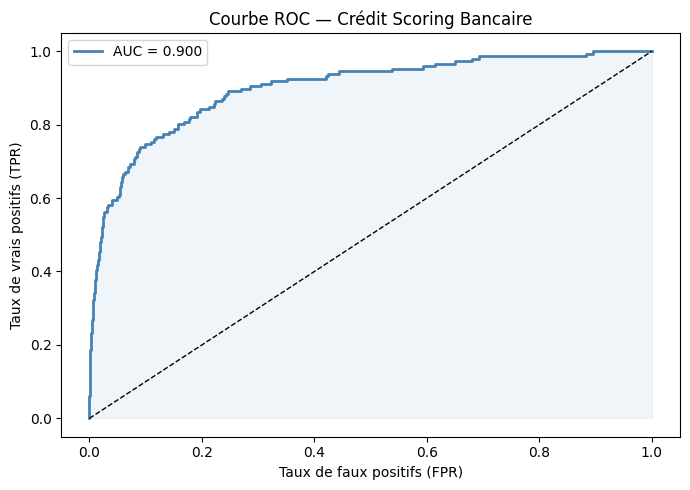

In [11]:
# Author: Octo Technology MLOps Tribe
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {METRICS['auc_roc']:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.fill_between(fpr, tpr, alpha=0.08, color="steelblue")
ax.set_xlabel("Taux de faux positifs (FPR)")
ax.set_ylabel("Taux de vrais positifs (TPR)")
ax.set_title("Courbe ROC — Crédit Scoring Bancaire")
ax.legend()
plt.tight_layout()
roc_path = ARTIFACTS_DIR / "roc_curve.png"
plt.savefig(roc_path, dpi=150)
plt.show()

## 8. Analyse d'équité (Fairness)

In [12]:
# Author: Octo Technology MLOps Tribe
df_eval = X_test.copy()
df_eval["default"]      = y_test.values
df_eval["predicted"]    = y_pred
df_eval["proba"]        = y_proba
df_eval["age_group"]    = pd.cut(df_eval["age"],    bins=AGE_BINS, labels=AGE_LABELS)
df_eval["income_bracket"] = pd.cut(df_eval["income"], bins=INC_BINS, labels=INC_LABELS)


def subgroup_metrics(group: pd.DataFrame) -> dict:
    if len(group) < 20:
        return None
    try:
        auc = round(float(roc_auc_score(group["default"], group["proba"])), 4) if group["default"].nunique() > 1 else "N/A"
    except Exception:
        auc = "N/A"
    return {
        "n":            int(len(group)),
        "default_rate": round(float(group["default"].mean()), 4),
        "accuracy":     round(float(accuracy_score(group["default"], group["predicted"])), 4),
        "recall":       round(float(recall_score(group["default"],    group["predicted"], zero_division=0)), 4),
        "precision":    round(float(precision_score(group["default"], group["predicted"], zero_division=0)), 4),
        "auc_roc":      auc,
    }


fairness_by_age    = {str(k): subgroup_metrics(v) for k, v in df_eval.groupby("age_group",      observed=True)}
fairness_by_income = {str(k): subgroup_metrics(v) for k, v in df_eval.groupby("income_bracket", observed=True)}

FAIRNESS_REPORT = {
    "protected_attributes": PROTECTED_ATTRIBUTES,
    "note": "L'âge et le revenu sont des attributs sensibles au sens du droit européen (RGPD Art. 9 & AI Act Art. 10). Leur usage doit être validé juridiquement.",
    "by_age_group":      fairness_by_age,
    "by_income_bracket": fairness_by_income,
}

print("=== Performance par tranche d'âge ===")
print(pd.DataFrame(fairness_by_age).T.to_string())
print("\n=== Performance par tranche de revenu ===")
print(pd.DataFrame(fairness_by_income).T.to_string())

=== Performance par tranche d'âge ===
           n  default_rate  accuracy  recall  precision  auc_roc
18-30  280.0        0.0893    0.9214  0.2800     0.6364   0.9034
31-45  528.0        0.0947    0.9356  0.5400     0.7105   0.8898
46-60  488.0        0.0881    0.9385  0.5349     0.6970   0.9080
60+    304.0        0.0921    0.9375  0.4643     0.7647   0.9053

=== Performance par tranche de revenu ===
              n  default_rate  accuracy  recall  precision  auc_roc
<30k      174.0        0.4023    0.8103  0.7714     0.7606   0.8978
30k-60k   369.0        0.1301    0.8862  0.3333     0.6154   0.8302
60k-100k  476.0        0.0336    0.9622  0.0000     0.0000   0.8433
>100k     581.0        0.0207    0.9793  0.0000     0.0000   0.6718


## 9. Explicabilité

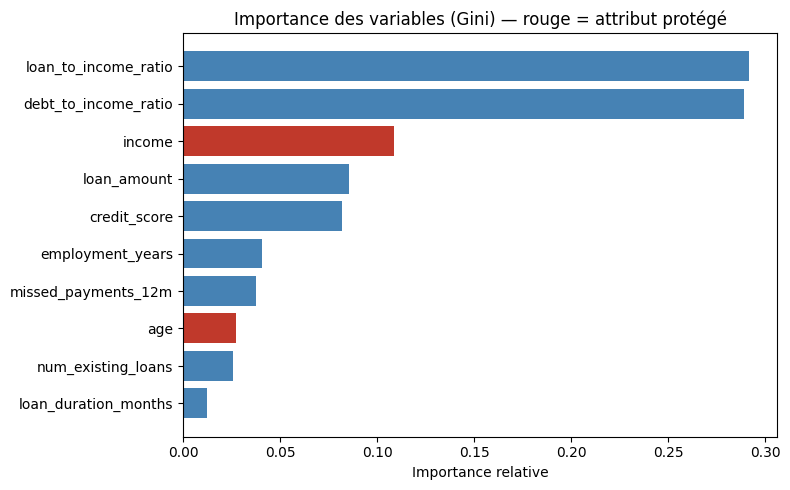

             feature  importance
loan_to_income_ratio    0.291594
debt_to_income_ratio    0.289197
              income    0.108496
         loan_amount    0.085328
        credit_score    0.082123
    employment_years    0.040503
 missed_payments_12m    0.037386
                 age    0.027172
  num_existing_loans    0.025604
loan_duration_months    0.012598


In [13]:
# Author: Octo Technology MLOps Tribe
importances = model.feature_importances_
fi_df = pd.DataFrame({"feature": FEATURES, "importance": importances}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#c0392b" if f in PROTECTED_ATTRIBUTES else "steelblue" for f in fi_df["feature"][::-1]]
ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color=colors)
ax.set_title("Importance des variables (Gini) — rouge = attribut protégé")
ax.set_xlabel("Importance relative")
plt.tight_layout()
fi_path = ARTIFACTS_DIR / "feature_importance.png"
plt.savefig(fi_path, dpi=150)
plt.show()
print(fi_df.to_string(index=False))

In [14]:
# Author: Octo Technology MLOps Tribe
SHAP_AVAILABLE = False
try:
    import shap
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_sc.iloc[:300])

    plt.figure()
    shap.summary_plot(shap_values, X_test_sc.iloc[:300], show=False, plot_size=(10, 6))
    shap_path = ARTIFACTS_DIR / "shap_summary.png"
    plt.savefig(shap_path, dpi=150, bbox_inches="tight")
    plt.close()
    SHAP_AVAILABLE = True
    print("SHAP summary plot généré.")
except ImportError:
    print("SHAP non disponible — installer avec : pip install shap")

SHAP summary plot généré.


## 10. Préparation des artefacts de documentation

In [15]:
# Author: Octo Technology MLOps Tribe
# ── classification report JSON ────────────────────────────────────────────────
cr_path = ARTIFACTS_DIR / "classification_report.json"
with open(cr_path, "w") as f:
    json.dump(report_dict, f, indent=2, ensure_ascii=False)

# ── feature importance CSV ────────────────────────────────────────────────────
fi_csv_path = ARTIFACTS_DIR / "feature_importance.csv"
fi_df.to_csv(fi_csv_path, index=False)

# ── fairness report JSON ──────────────────────────────────────────────────────
fairness_path = ARTIFACTS_DIR / "fairness_report.json"
with open(fairness_path, "w") as f:
    json.dump(FAIRNESS_REPORT, f, indent=2, ensure_ascii=False)

# ── preprocessing description (Markdown) — read from external template ────────
pp_context = {
    "schema_name":    CREDIT_SCHEMA.name,
    "pandera_status": PANDERA_STATUS,
    "pandera_errors": PANDERA_ERRORS,
}
preprocessing_md = Path("preprocessing_description_template.md").read_text(encoding="utf-8").format_map(pp_context)
pp_path = ARTIFACTS_DIR / "preprocessing_description.md"
pp_path.write_text(preprocessing_md, encoding="utf-8")

print("Artefacts préparés :")
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(f"  {p.name}")

Artefacts préparés :
  classification_report.json
  data_validation_report.json
  fairness_report.json
  feature_importance.csv
  feature_importance.png
  pandera_schema.yaml
  preprocessing_description.md
  roc_curve.png
  shap_summary.png


## 11. Logging MLflow

In [16]:
# Author: Octo Technology MLOps Tribe
MODEL_NAME  = "credit_default_predictor"
TEAM        = "mlops-tribe"
ENVIRONMENT = "staging"

# ── Model card — copie depuis le fichier édité par le DS ──────────────────────
model_card_text = Path("model_card.md").read_text(encoding="utf-8")
model_card_path = ARTIFACTS_DIR / "model_card.md"
model_card_path.write_text(model_card_text, encoding="utf-8")

with mlflow.start_run(run_name=f"{MODEL_NAME}_v1") as run:

    # ── Hyperparamètres ───────────────────────────────────────────────────────
    mlflow.log_params(PARAMS)
    mlflow.log_param("scaler",           "StandardScaler")
    mlflow.log_param("feature_count",    len(FEATURES))
    mlflow.log_param("features",         ", ".join(FEATURES))
    mlflow.log_param("stratified_split", True)
    mlflow.log_param("train_size",       len(X_train))
    mlflow.log_param("val_size",         len(X_val))
    mlflow.log_param("test_size",        len(X_test))

    # ── Métriques de performance ──────────────────────────────────────────────
    mlflow.log_metrics(METRICS)
    mlflow.log_metric("auc_roc_validation", round(val_auc, 4))
    mlflow.log_metric("default_rate_train", round(float(y_train.mean()), 4))
    mlflow.log_metric("default_rate_test",  round(float(y_test.mean()),  4))
    mlflow.log_metric("dataset_total_size", N)

    # ── Tags — identification ─────────────────────────────────────────────────
    mlflow.set_tag("team",        TEAM)
    mlflow.set_tag("environment", ENVIRONMENT)
    mlflow.set_tag("model_type",  "GradientBoostingClassifier")
    mlflow.set_tag("framework",   "scikit-learn")

    # ── Tags — données & schéma ───────────────────────────────────────────────
    mlflow.set_tag("data_source",            "Données synthétiques — distribution calibrée sur données réelles de crédit")
    mlflow.set_tag("data_period",            "N/A — données synthétiques")
    mlflow.set_tag("data_language",          "N/A — données tabulaires")
    mlflow.set_tag("contains_personal_data", "oui — âge, revenu (attributs protégés au sens RGPD / AI Act Art. 10)")
    mlflow.set_tag("dataset_size",           f"train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")
    mlflow.set_tag("protected_attributes",   ", ".join(PROTECTED_ATTRIBUTES))
    mlflow.set_tag("data_schema_name",       CREDIT_SCHEMA.name)
    mlflow.set_tag("data_schema_version",    "1.0")
    mlflow.set_tag("pandera_validation",     PANDERA_STATUS)

    # ── Tags — seuils d'acceptation ───────────────────────────────────────────
    mlflow.set_tag("threshold_accuracy",  "0.80")
    mlflow.set_tag("threshold_f1",        "0.75")
    mlflow.set_tag("threshold_auc_roc",   "0.82")
    mlflow.set_tag("threshold_recall",    "0.70")

    # ── Tags — AI Act : classification du risque ──────────────────────────────
    mlflow.set_tag("ai_act_risk_level",         "élevé")
    mlflow.set_tag("ai_act_annex_iii_category", "§5b — Évaluation de la solvabilité et scoring de crédit")

    # ── Tag — Model Card (permet la conformité déterministe) ──────────────────
    mlflow.set_tag("mlflow.note.content", model_card_text)

    # ── Artefacts ─────────────────────────────────────────────────────────────
    mlflow.log_artifact(str(cr_path))
    mlflow.log_artifact(str(fi_csv_path))
    mlflow.log_artifact(str(fi_path))
    mlflow.log_artifact(str(fairness_path))
    mlflow.log_artifact(str(roc_path))
    mlflow.log_artifact(str(pp_path))
    mlflow.log_artifact(str(validation_report_path))
    if SCHEMA_YAML_EXPORTED:
        mlflow.log_artifact(str(schema_yaml_path))
    if SHAP_AVAILABLE:
        mlflow.log_artifact(str(shap_path))
    mlflow.log_artifact(str(model_card_path))

    # ── Modèle ────────────────────────────────────────────────────────────────
    signature     = infer_signature(X_train_sc, model.predict_proba(X_train_sc))
    input_example = X_train_sc.head(3)

    mlflow.sklearn.log_model(
        sk_model=model,
        name="custom_model",
        registered_model_name=MODEL_NAME,
        signature=signature,
        input_example=input_example,
    )

    run_id = run.info.run_id

print(f"\n✅ Run MLflow : {run_id}")
print(f"   Modèle enregistré : {MODEL_NAME}")
print(f"   AUC-ROC : {METRICS['auc_roc']}  |  F1 : {METRICS['f1_score']}  |  Accuracy : {METRICS['accuracy']}")
print(f"   Pandera : {PANDERA_STATUS}")
print(f"   mlflow.note.content : ✅ (model card injectée dans les tags)")

2026/06/02 09:55:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/02 09:55:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Successfully registered model 'credit_default_predictor'.
2026/06/02 09:55:55 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit_default_predictor, version 1


🏃 View run credit_default_predictor_v1 at: http://model-platform.com/registry/Credit-Risk-Assessment/#/experiments/1/runs/77d7630255ac46bba56035e76a804d68
🧪 View experiment at: http://model-platform.com/registry/Credit-Risk-Assessment/#/experiments/1

✅ Run MLflow : 77d7630255ac46bba56035e76a804d68
   Modèle enregistré : credit_default_predictor
   AUC-ROC : 0.9003  |  F1 : 0.5714  |  Accuracy : 0.9344
   Pandera : PASS
   mlflow.note.content : ✅ (model card injectée dans les tags)


Created version '1' of model 'credit_default_predictor'.
